
                                                                              ДАННЫЕ РПЛ 2024/2025                                                                              
╒═════╤═══════════════════════════╤══════════════════╤══════════════════════════╤═════════════════╤════════════════════╤═══════════════════╤══════════════╤════════════════════╕
│  №  │       Дата и время        │      Город       │         Стадион          │     Хозяева     │       Гости        │  Температура, °C  │  Время года  │  Погодные условия  │
╞═════╪═══════════════════════════╪══════════════════╪══════════════════════════╪═════════════════╪════════════════════╪═══════════════════╪══════════════╪════════════════════╡
│  1  │ 2024-07-20T15:00:00+03:00 │      Moskva      │        RZD Arena         │    Lokomotiv    │       Akron        │        23         │     Лето     │       Дождь        │
├─────┼───────────────────────────┼──────────────────┼──────────────────────────┼─────────────────┼───────────────

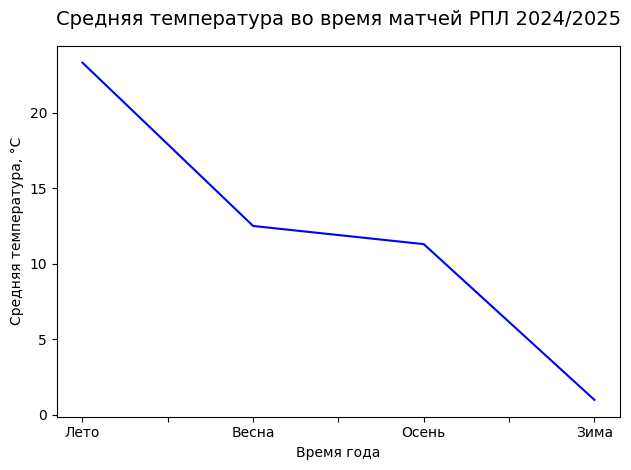

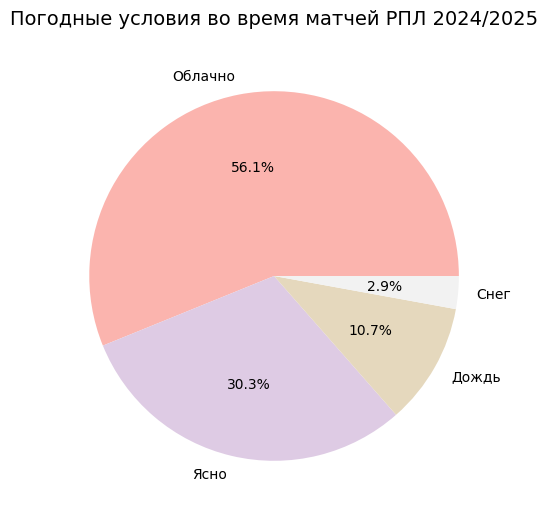

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from dotenv import load_dotenv
from tabulate import tabulate
from sqlalchemy import create_engine

load_dotenv()

# Получение параметров подключения
def get_match_stats():
    """
    Подключается к PostgreSQL с помощью SQLAlchemy и 
    через SQL-запросы получает таблицы для анализа
    """
    db_user = os.getenv("DB_USER")
    db_password = os.getenv("DB_PASSWORD")
    db_host = os.getenv("DB_HOST", "localhost")
    db_port = os.getenv("DB_PORT", "5432")
    db_name = os.getenv("DB_NAME")
    db_url = f"postgresql+psycopg2://{db_user}:{db_password}@{db_host}:{db_port}/{db_name}"
    engine = create_engine(db_url)
    
    # Общая таблица
    sql_all = """
    SELECT
        ROW_NUMBER() OVER (ORDER BY date_time ASC) AS "№",
        date_time AS "Дата и время",
        city AS "Город",
        stadium AS "Стадион",
        home_team AS "Хозяева",
        away_team AS "Гости",
        temperature AS "Температура, °C",
        season AS "Время года",
        weather_condition AS "Погодные условия"
    FROM public.rpl_matches_weather
    ORDER BY date_time ASC, match_id ASC 
    LIMIT 10
    """
    
    # Средняя температура
    sql_temp = """
    SELECT 
        season AS "Время года", 
        ROUND(AVG(temperature)::numeric, 1) AS "Средняя температура"
    FROM public.rpl_matches_weather
    GROUP BY season
    ORDER BY "Средняя температура" DESC
    """
    
    # Топ-3 погоды
    sql_weather = """
    SELECT 
        weather_condition AS "Погодные условия", 
        COUNT(*) AS "Количество матчей"
    FROM public.rpl_matches_weather
    GROUP BY weather_condition
    ORDER BY "Количество матчей" DESC
    LIMIT 3
    """
    
    # Погода и кол-во матчей
    sql_all_weather = """
    SELECT
        weather_condition AS "Погодные условия",
        COUNT(match_id) AS "Количество матчей"
    FROM public.rpl_matches_weather
    GROUP BY weather_condition
    ORDER BY "Количество матчей" DESC
    """
    df_all = pd.read_sql_query(sql_all, engine)
    df_temp = pd.read_sql_query(sql_temp, engine)
    df_weather = pd.read_sql_query(sql_weather, engine)
    df_all_weather = pd.read_sql_query(sql_all_weather, engine)
    
    return df_all, df_temp, df_weather, df_all_weather

if __name__ == "__main__":
    df_all, df_temp, df_weather, df_all_weather = get_match_stats()

    table_all = tabulate(
        df_all.values, 
        headers=df_all.columns, 
        tablefmt="fancy_grid", 
        colalign=("center",) * 9,       
    )

    width_all = len(table_all.split('\n')[0])
    print("\n" + "ДАННЫЕ РПЛ 2024/2025".center(width_all))
    print(table_all)
    
    table_avg = tabulate(
        df_temp.values,
        headers=df_temp.columns,
        tablefmt="fancy_grid", 
        colalign=("center",) * 2, 
    )

    width_avg = len(table_avg.split('\n')[0])
    print("\n" + "СРЕДНЯЯ ТЕМПЕРАТУРА МАТЧЕЙ".center(width_avg))
    print(table_avg)

    table_weather = tabulate(
        df_weather.values,
        headers=df_weather.columns, 
        tablefmt="fancy_grid", 
        colalign=("center",) * 2,           
    )

    width_weather = len(table_weather.split('\n')[0])
    print("\n" + "ТОП-3 ПОГОДЫ".center(width_weather))
    print(table_weather)

    # Линейный график df_temp
    df_temp.plot(x='Время года', y='Средняя температура', kind='line', legend=False, color='blue')
    plt.title('Средняя температура во время матчей РПЛ 2024/2025', fontsize=14, pad=15)
    plt.ylabel('Средняя температура, °C')
    plt.xticks(rotation=0)
    plt.tight_layout()

    # Круговая диаграмма df_all_weather
    df_all_weather.plot(
        kind='pie',
        y='Количество матчей',
        labels=df_all_weather['Погодные условия'],
        autopct='%.1f%%',
        figsize=(6, 6),
        legend=False,
        cmap='Pastel1'
    )
    plt.title('Погодные условия во время матчей РПЛ 2024/2025', fontsize=14, pad=15)

